# Week 12: Time Series Analysis

**QM 2023 — Statistics II / Data Analytics**  
**Spring 2026 | University of Tulsa**

---

## What You Will Learn

By the end of this notebook, you should be able to:

1. Explain what makes time-series data different from the cross-sectional datasets we used earlier.
2. Distinguish between a stationary series and a non-stationary series.
3. Read ACF and PACF plots at a beginner level.
4. Use the Augmented Dickey-Fuller test to check for a unit root.
5. Fit a simple autoregressive model and judge whether it is doing a reasonable job.
6. Interpret a forecast without overstating how precise it is.

---

## How To Use This Notebook

This notebook is written as a walkthrough, not just a collection of code cells.

- Run the cells from top to bottom.
- After each major output, pause at the interpretation checkpoint.
- Focus first on the direction of the result before worrying about every number.

## The Main Question

We will study monthly REIT returns. The goal is not to prove that returns are easy to predict. In fact, the data will show the opposite: returns are **stationary**, but they are still **hard to forecast precisely**.

That distinction matters a lot for beginners:

- A series can be statistically well-behaved enough to model.
- But it can still contain only a small amount of predictable structure.

---

## Section 1: Setup and Data Loading

We begin by importing the packages used throughout the notebook.

A few are familiar:

- `pandas` for data handling
- `numpy` for numerical work
- `matplotlib` for plots

The new package this week is `statsmodels`, which gives us standard time-series tools such as:

- ACF and PACF plots
- the Augmented Dickey-Fuller test
- autoregressive models

**Run the next cell first.** It sets the plotting style and loads the functions used later.

In [18]:
# =============================================================================
# ALL IMPORTS — Run this cell first
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from IPython.display import display

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.stats.diagnostic import acorr_ljungbox

%matplotlib inline

# Consistent notebook styling
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["grid.alpha"] = 0.25
pd.options.display.float_format = "{:,.3f}".format

# =============================================================================
# COLOR PALETTE
# =============================================================================
COLOR_RETURNS = "#2A6F97"
COLOR_PRICE = "#386641"
COLOR_FORECAST = "#BC4749"
COLOR_CI = "#F2CC8F"
COLOR_RESIDUAL = "#7B2CBF"
COLOR_MOMENTUM = "#D17B0F"
COLOR_STATIONARY = "#2A6F97"
COLOR_RANDOM_WALK = "#BC4749"
COLOR_WHITENOISE = "#4D908E"
COLOR_DRIFT = "#9C6644"

DEMOS_DIR = Path(".")


def print_rule(title):
    print()
    print("=" * 72)
    print(title)
    print("=" * 72)


print("Imports complete. Notebook styling is set.")
print("This walkthrough uses the global Python environment and standard monthly time-series tools.")

Imports complete. Notebook styling is set.
This walkthrough uses the global Python environment and standard monthly time-series tools.


### Load the REIT Factor Data

The dataset is `factors_master_long_only.csv`.

Each row is one month, and the main variable we care about is:

| Variable | Description |
|----------|-------------|
| `vwtret` | Value-weighted REIT return in percent |
| `ewtret` | Equal-weighted REIT return in percent |
| `mom_long` | Momentum factor return in percent |
| `date` | Month in `YYYYMM` form |

We will first inspect the raw file, then convert the date column into a proper monthly time index.

In [19]:
# =============================================================================
# LOAD DATA
# =============================================================================
data_path = Path("data/factors_master_long_only.csv")
df_factors_raw = pd.read_csv(data_path)

print_rule("Raw Data Overview")
print(f"Rows:    {df_factors_raw.shape[0]}")
print(f"Columns: {df_factors_raw.shape[1]}")
print(f"Column names: {df_factors_raw.columns.tolist()}")

display(df_factors_raw.head())


Raw Data Overview
Rows:    470
Columns: 11
Column names: ['date', 'ewtret', 'vwtret', 'size_long', 'value_long', 'value_reit_long', 'mom_long', 'qual_long', 'qual_reit_long', 'lowvol_long', 'rev_long']


,date,ewtret,vwtret,size_long,value_long,value_reit_long,mom_long,qual_long,qual_reit_long,lowvol_long,rev_long
0,198612,3.621,2.156,15.256,0.411,NaN,2.881,4.962,2.681,2.259,1.350
1,198701,1.993,3.220,-2.085,-0.155,NaN,1.639,1.158,3.474,1.669,1.765
2,198702,0.511,0.237,-0.440,6.147,NaN,0.076,-3.125,-3.616,-1.797,5.030
3,198703,-2.580,-2.758,-0.804,2.568,NaN,-2.653,1.703,-3.284,0.360,-3.677
4,198704,-0.768,-1.071,-2.644,-1.644,NaN,0.154,-0.908,0.357,0.414,2.356


In [20]:
# =============================================================================
# DATE PARSING AND INDEXING
# =============================================================================
df_factors = df_factors_raw.copy()
df_factors["date"] = pd.to_datetime(df_factors["date"].astype(str), format="%Y%m")
df_factors = df_factors.set_index("date").sort_index()
df_factors = df_factors.dropna(subset=["vwtret"])
df_factors = df_factors.asfreq("MS")

vwtret_series = df_factors["vwtret"]

summary_table = pd.DataFrame(
    {
        "Statistic": ["Observations", "Start", "End", "Mean return (%)", "Std. dev. (%)"],
        "Value": [
            len(vwtret_series),
            vwtret_series.index.min().strftime("%B %Y"),
            vwtret_series.index.max().strftime("%B %Y"),
            round(vwtret_series.mean(), 3),
            round(vwtret_series.std(), 3),
        ],
    }
)

print_rule("Cleaned Time-Series Sample")
display(summary_table)

print("Five-number summary for monthly REIT returns (%):")
display(vwtret_series.describe().round(3).to_frame(name="vwtret"))


Cleaned Time-Series Sample


,Statistic,Value
0,Observations,456
1,Start,December 1986
2,End,November 2024
3,Mean return (%),0.807
4,Std. dev. (%),5.077


Five-number summary for monthly REIT returns (%):


,vwtret
count,456.000
mean,0.807
std,5.077
min,-30.212
25%,-1.720
50%,1.094
75%,3.598
max,27.881


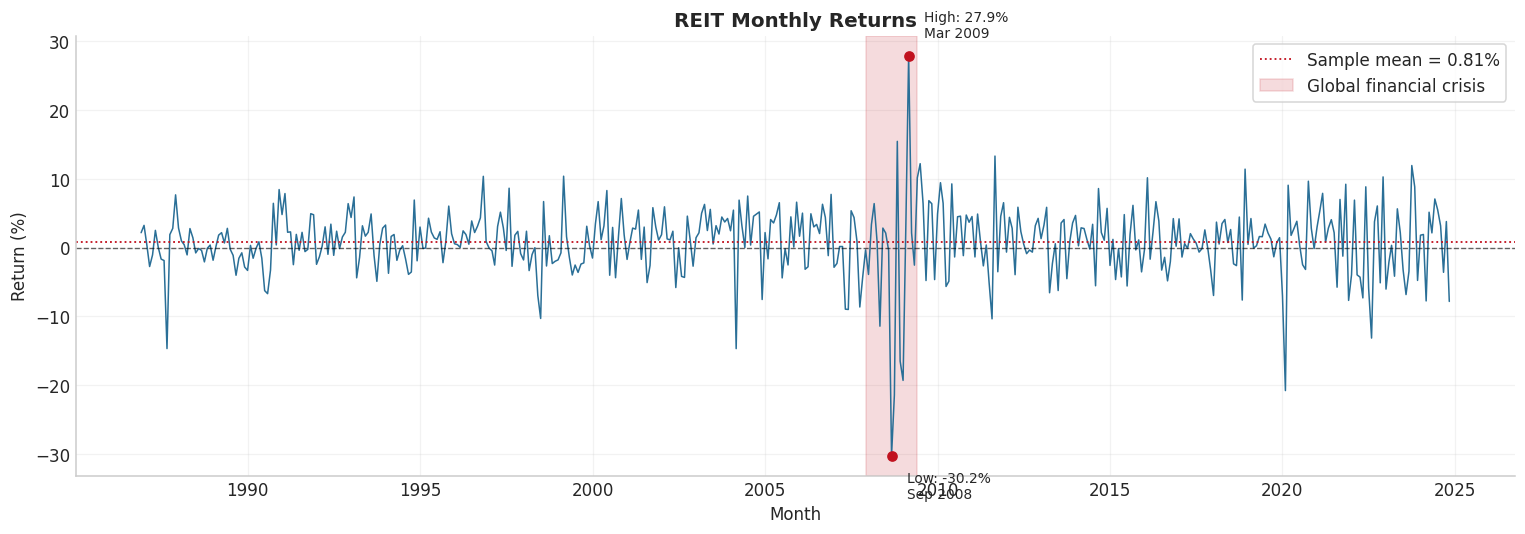


What The Plot Shows
Average monthly return: 0.81%
Largest gain: 27.88% in Mar 2009
Largest loss: -30.21% in Sep 2008


In [21]:
# =============================================================================
# CHART 1 — Full history of REIT value-weighted returns
# =============================================================================
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(vwtret_series.index, vwtret_series.values, color=COLOR_RETURNS, linewidth=1.0)
ax.axhline(0, color="black", linewidth=0.9, linestyle="--", alpha=0.6)
ax.axhline(vwtret_series.mean(), color="#C1121F", linewidth=1.2, linestyle=":", label=f"Sample mean = {vwtret_series.mean():.2f}%")

crisis_start = pd.Timestamp("2007-12-01")
crisis_end = pd.Timestamp("2009-06-01")
ax.axvspan(crisis_start, crisis_end, alpha=0.15, color="#C1121F", label="Global financial crisis")

max_date = vwtret_series.idxmax()
min_date = vwtret_series.idxmin()
ax.scatter([max_date, min_date], [vwtret_series.max(), vwtret_series.min()], color="#C1121F", zorder=3)
ax.annotate(f"High: {vwtret_series.max():.1f}%\n{max_date.strftime('%b %Y')}", xy=(max_date, vwtret_series.max()), xytext=(10, 12), textcoords="offset points", fontsize=9)
ax.annotate(f"Low: {vwtret_series.min():.1f}%\n{min_date.strftime('%b %Y')}", xy=(min_date, vwtret_series.min()), xytext=(10, -28), textcoords="offset points", fontsize=9)

ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title("REIT Monthly Returns", fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Return (%)")
ax.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.savefig(DEMOS_DIR / "fig01_returns_history.png", dpi=150, bbox_inches="tight")
plt.show()

print_rule("What The Plot Shows")
print(f"Average monthly return: {vwtret_series.mean():.2f}%")
print(f"Largest gain: {vwtret_series.max():.2f}% in {max_date.strftime('%b %Y')}")
print(f"Largest loss: {vwtret_series.min():.2f}% in {min_date.strftime('%b %Y')}")

---

## Section 2: What Is a Time Series?

A time series is a variable observed repeatedly over time. The order matters.

That is the big difference from a cross-section:

- In a cross-section, row 10 and row 11 usually have no natural ordering.
- In a time series, March comes after February for a reason.

A useful beginner habit is to look at the same data in two ways:

- the **return series**, which shows month-to-month changes
- the **price index**, which shows what happens after those monthly changes compound over time

Those two views help explain why economists usually model **returns** rather than **price levels**.

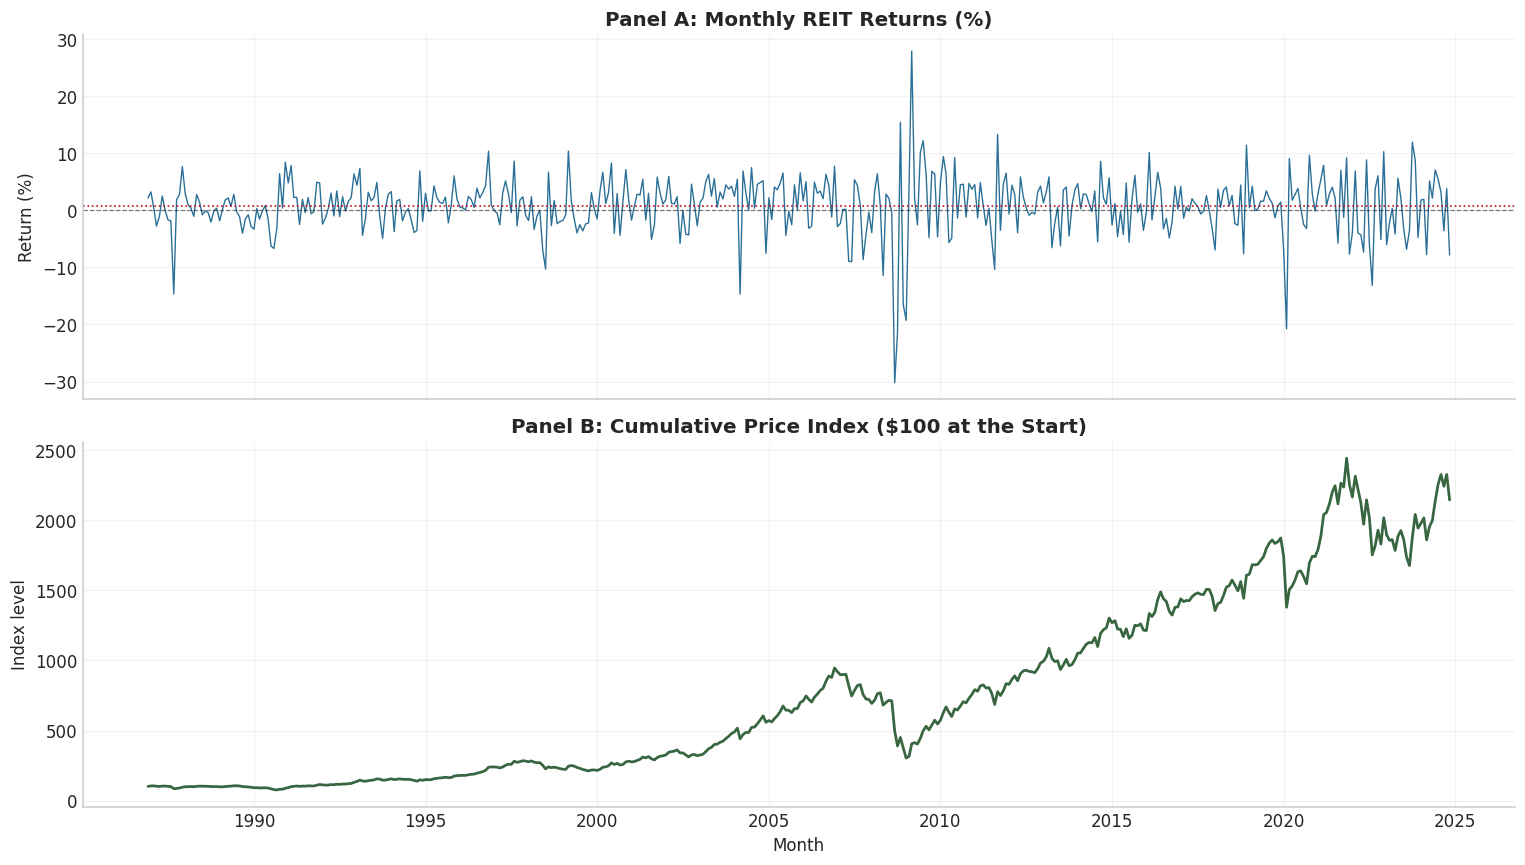


Compounding Insight
$100 at the start grows to about $2144.
That is roughly a 21.0x increase over the sample.


In [22]:
# =============================================================================
# CHART 2 — Return series vs. cumulative price index
# =============================================================================
reit_price_index = (1 + vwtret_series / 100).cumprod() * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(vwtret_series.index, vwtret_series.values, color=COLOR_RETURNS, linewidth=0.9)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
axes[0].axhline(vwtret_series.mean(), color="#C1121F", linewidth=1.1, linestyle=":")
axes[0].set_title("Panel A: Monthly REIT Returns (%)", fontweight="bold")
axes[0].set_ylabel("Return (%)")

axes[1].plot(reit_price_index.index, reit_price_index.values, color=COLOR_PRICE, linewidth=1.8)
axes[1].set_title("Panel B: Cumulative Price Index ($100 at the Start)", fontweight="bold")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Index level")
axes[1].xaxis.set_major_locator(mdates.YearLocator(5))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig(DEMOS_DIR / "fig02_returns_vs_price_index.png", dpi=150, bbox_inches="tight")
plt.show()

total_return_multiplier = reit_price_index.iloc[-1] / reit_price_index.iloc[0]
print_rule("Compounding Insight")
print(f"$100 at the start grows to about ${reit_price_index.iloc[-1]:.0f}.")
print(f"That is roughly a {total_return_multiplier:.1f}x increase over the sample.")

### Interpretation Checkpoint

The two panels tell different stories even though they come from the same underlying data.

- The **return series** fluctuates around a fairly stable average of about **0.81% per month**.
- The **price index** trends upward because positive returns compound over time.

For beginners, this is the key lesson:

- A series can look noisy and roughly stable when written as returns.
- The same information can look trending and non-stationary when written as a level.

That is why later sections focus on **returns**, not the price index itself.

---

## Section 3: Stationarity

Stationarity is one of the central ideas in time-series analysis.

A series is called **stationary** when its overall behavior is stable over time:

- the mean does not drift upward or downward indefinitely
- the variance stays in roughly the same range
- the relationship with past values does not keep changing

Why do we care?

Because most standard time-series models assume that the series is not wandering away without limit.

A useful intuition is this:

- A stationary series has a kind of statistical center.
- A non-stationary series can drift for long periods without returning to that center.

The simulated examples below are meant to build that intuition before we turn back to the real REIT data.

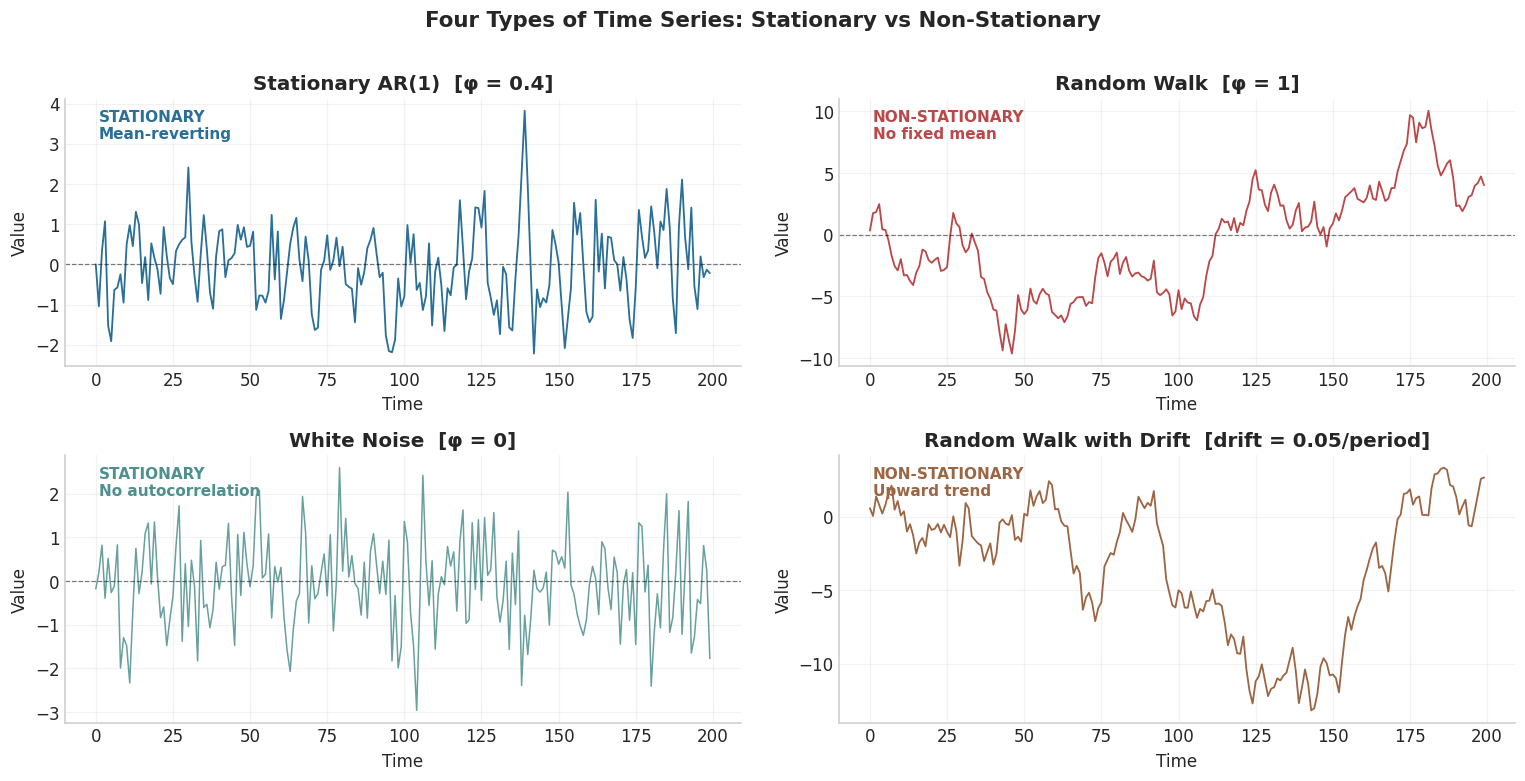

Chart saved: fig03_stationarity_examples.png


In [23]:
# =============================================================================
# CHART 3 — Four simulated series: see stationarity vs non-stationarity
# =============================================================================
# We use a fixed random seed so the charts look the same every time you run them
rng = np.random.default_rng(seed=42)

n_obs = 200   # Number of simulated time points

# --- Series 1: Stationary AR(1) with phi = 0.4 ---
# Each value = 0.4 × last value + random shock
# Because phi < 1, the series is pulled back toward zero
phi_stationary = 0.4
shocks_ar1 = rng.normal(0, 1, n_obs)
series_stationary = np.zeros(n_obs)
for t in range(1, n_obs):
    series_stationary[t] = phi_stationary * series_stationary[t - 1] + shocks_ar1[t]

# --- Series 2: Random walk (unit root, phi = 1) ---
# Each value = last value + random shock
# No restoring force → series wanders with no fixed mean
shocks_rw = rng.normal(0, 1, n_obs)
series_random_walk = np.cumsum(shocks_rw)   # Cumulative sum = random walk

# --- Series 3: White noise (phi = 0) ---
# Each value is a completely independent random draw — the simplest stationary series
series_white_noise = rng.normal(0, 1, n_obs)

# --- Series 4: Random walk with drift ---
# Like a random walk, but with a positive trend added each period
drift_per_period = 0.05
shocks_drift = rng.normal(0, 1, n_obs)
series_drift = np.cumsum(shocks_drift + drift_per_period)

# --- Plot all four series ---
time_axis = np.arange(n_obs)

fig, axes = plt.subplots(2, 2, figsize=(14, 7))

# Top-left: Stationary AR(1)
axes[0, 0].plot(time_axis, series_stationary, color=COLOR_STATIONARY, linewidth=1.2)
axes[0, 0].axhline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
axes[0, 0].set_title("Stationary AR(1)  [φ = 0.4]", fontweight="bold")
axes[0, 0].set_ylabel("Value")
axes[0, 0].set_xlabel("Time")
axes[0, 0].annotate("STATIONARY\nMean-reverting", xy=(0.05, 0.85),
                    xycoords="axes fraction", fontsize=10, color=COLOR_STATIONARY,
                    fontweight="bold")

# Top-right: Random walk
axes[0, 1].plot(time_axis, series_random_walk, color=COLOR_RANDOM_WALK, linewidth=1.2)
axes[0, 1].axhline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
axes[0, 1].set_title("Random Walk  [φ = 1]", fontweight="bold")
axes[0, 1].set_ylabel("Value")
axes[0, 1].set_xlabel("Time")
axes[0, 1].annotate("NON-STATIONARY\nNo fixed mean", xy=(0.05, 0.85),
                    xycoords="axes fraction", fontsize=10, color=COLOR_RANDOM_WALK,
                    fontweight="bold")

# Bottom-left: White noise
axes[1, 0].plot(time_axis, series_white_noise, color=COLOR_WHITENOISE, linewidth=1.0, alpha=0.85)
axes[1, 0].axhline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
axes[1, 0].set_title("White Noise  [φ = 0]", fontweight="bold")
axes[1, 0].set_ylabel("Value")
axes[1, 0].set_xlabel("Time")
axes[1, 0].annotate("STATIONARY\nNo autocorrelation", xy=(0.05, 0.85),
                    xycoords="axes fraction", fontsize=10, color=COLOR_WHITENOISE,
                    fontweight="bold")

# Bottom-right: Random walk with drift
axes[1, 1].plot(time_axis, series_drift, color=COLOR_DRIFT, linewidth=1.2)
axes[1, 1].set_title("Random Walk with Drift  [drift = 0.05/period]", fontweight="bold")
axes[1, 1].set_ylabel("Value")
axes[1, 1].set_xlabel("Time")
axes[1, 1].annotate("NON-STATIONARY\nUpward trend", xy=(0.05, 0.85),
                    xycoords="axes fraction", fontsize=10, color=COLOR_DRIFT,
                    fontweight="bold")

fig.suptitle("Four Types of Time Series: Stationary vs Non-Stationary",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(DEMOS_DIR / "fig03_stationarity_examples.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: fig03_stationarity_examples.png")

### Interpretation Checkpoint

The simulated plots are a visual warm-up for the real data.

A reasonable first impression is:

- REIT **returns** look more like the stationary examples because they bounce around a stable level.
- The REIT **price index** looks more like a drifting series because it keeps moving upward over long horizons.

This is only a visual judgment so far. In a few sections we will test that idea formally with the ADF test.

---

## Section 4: Autocorrelation, ACF, and PACF

Once we know which series to model, the next question is whether the current month depends on earlier months.

### ACF

The autocorrelation function measures the correlation between the series and its own lagged values.

$$\rho_k = \text{Corr}(r_t, r_{t-k})$$

If the lag-2 autocorrelation is noticeably different from zero, then returns two months apart move together more than we would expect from pure noise.

### PACF

The partial autocorrelation function asks a slightly narrower question:

How much direct information does lag $k$ add **after** we account for the shorter lags?

That is why PACF is often used when deciding how many lags to include in an autoregressive model.

### How To Read The Bands

The confidence bands mark values that could easily occur if the true autocorrelation were zero.

- Bars inside the bands: consistent with noise
- Bars outside the bands: evidence of real autocorrelation

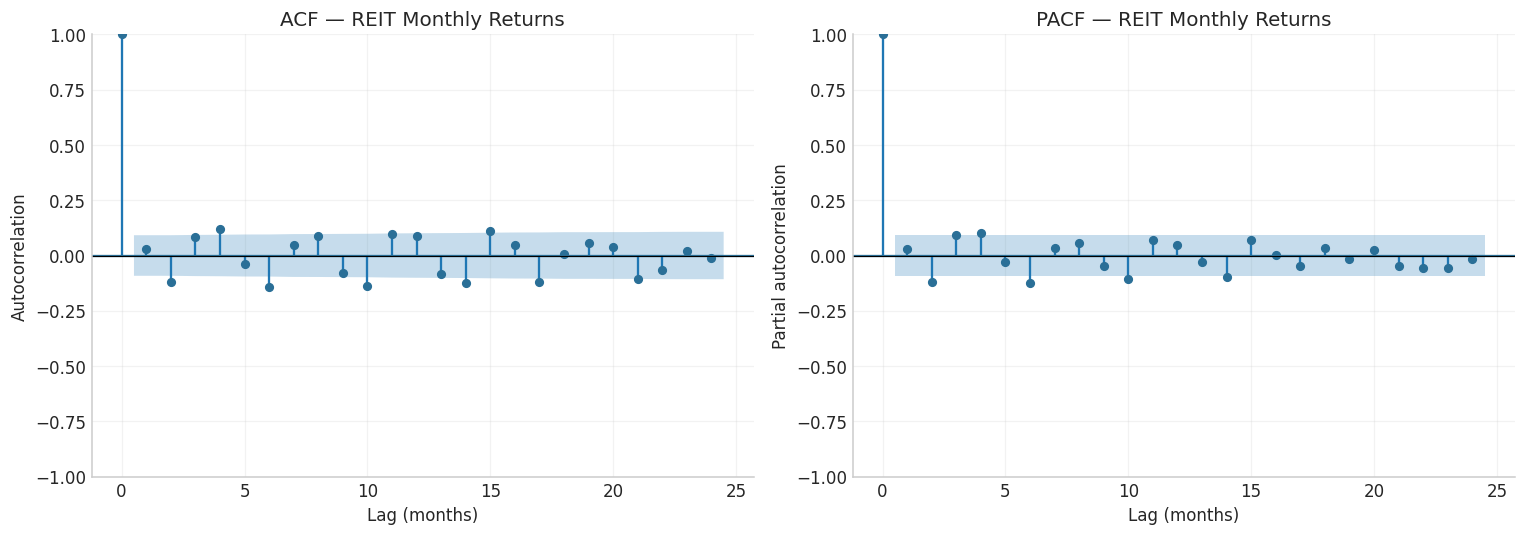


Sample Autocorrelation Summary
Approximate 95% cutoff: +/-0.092
Lag  1: +0.030 
Lag  2: -0.119 *
Lag  3: +0.085 
Lag  4: +0.119 *
Lag  5: -0.040 
Lag  6: -0.141 *

Lags outside the approximate 95% band (1-24): [2, 4, 6, 10, 11, 14, 15, 17, 21]


In [24]:
# =============================================================================
# CHART 4 — ACF and PACF of REIT monthly returns
# =============================================================================
vwtret_series = df_factors["vwtret"]
n_lags_to_show = 24

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(
    vwtret_series,
    lags=n_lags_to_show,
    ax=axes[0],
    color=COLOR_RETURNS,
    alpha=0.05,
    title="ACF — REIT Monthly Returns",
)
axes[0].set_xlabel("Lag (months)")
axes[0].set_ylabel("Autocorrelation")
axes[0].axhline(0, color="black", linewidth=0.7)

plot_pacf(
    vwtret_series,
    lags=n_lags_to_show,
    ax=axes[1],
    method="ywm",
    color=COLOR_RETURNS,
    alpha=0.05,
    title="PACF — REIT Monthly Returns",
)
axes[1].set_xlabel("Lag (months)")
axes[1].set_ylabel("Partial autocorrelation")
axes[1].axhline(0, color="black", linewidth=0.7)

plt.tight_layout()
plt.savefig(DEMOS_DIR / "fig04_acf_pacf_returns.png", dpi=150, bbox_inches="tight")
plt.show()

acf_values = acf(vwtret_series, nlags=6, fft=True)
acf_threshold = 1.96 / np.sqrt(len(vwtret_series))
significant_lags = [lag for lag in range(1, 25) if abs(acf(vwtret_series, nlags=24, fft=True)[lag]) > acf_threshold]

print_rule("Sample Autocorrelation Summary")
print(f"Approximate 95% cutoff: +/-{acf_threshold:.3f}")
for lag_num in range(1, 7):
    marker = "*" if abs(acf_values[lag_num]) > acf_threshold else ""
    print(f"Lag {lag_num:>2}: {acf_values[lag_num]:+.3f} {marker}")
print()
print(f"Lags outside the approximate 95% band (1-24): {significant_lags}")

### Interpretation Checkpoint

For this sample, the autocorrelation pattern is **not** a strong lag-1 story.

What stands out more is that a few higher lags are modestly outside the confidence band. In particular, the sample ACF suggests noticeable structure around lags 2, 4, and 6 rather than a single dominant lag-1 spike.

That matters for model choice:

- The data does not strongly support the claim that AR(1) is enough by itself.
- A low-order autoregressive model still makes sense.
- But we should let the information criteria decide which lag length fits this sample best.

---

## Section 5: The Augmented Dickey-Fuller Test

The plot gave us a visual guess. The ADF test gives us a formal test.

The hypotheses are:

$$H_0:\; \text{the series has a unit root and is non-stationary}$$
$$H_1:\; \text{the series is stationary}$$

Two practical rules are enough for this notebook:

- A **small p-value** means strong evidence against a unit root.
- A **more negative** test statistic means stronger evidence of stationarity.

We will compare two series:

1. monthly REIT returns
2. the cumulative REIT price index

This side-by-side comparison is useful because it shows how much the conclusion can change when we transform the same data.

In [ ]:
# =============================================================================
# ADF TEST — Returns
# =============================================================================
vwtret_series = df_factors["vwtret"]
reit_price_index = (1 + vwtret_series / 100).cumprod() * 100

adf_result_returns = adfuller(vwtret_series, autolag="AIC")
adf_stat_returns = adf_result_returns[0]
adf_pval_returns = adf_result_returns[1]
adf_crit_returns = adf_result_returns[4]

print_rule("ADF Test: REIT Monthly Returns")
print(f"Test statistic: {adf_stat_returns:.4f}")
print(f"p-value:        {adf_pval_returns:.6f}")
print("Critical values:")
for level, cval in adf_crit_returns.items():
    print(f"  {level}: {cval:.4f}")
print()
if adf_pval_returns < 0.05:
    print("Decision: Reject H0.")
    print("Interpretation: REIT monthly returns behave like a stationary series in this sample.")
else:
    print("Decision: Fail to reject H0.")
    print("Interpretation: The test does not give enough evidence of stationarity.")

ADF TEST: REIT Monthly Returns (vwtret)
Test statistic:  -9.1597
p-value:         0.000000
Critical values:
   1%: -3.4450
   5%: -2.8680
   10%: -2.5702

CONCLUSION: p < 0.05 → Reject H0 → SERIES IS STATIONARY


In [ ]:
# =============================================================================
# ADF TEST — Price Index
# =============================================================================
adf_result_price = adfuller(reit_price_index, autolag="AIC")
adf_stat_price = adf_result_price[0]
adf_pval_price = adf_result_price[1]
adf_crit_price = adf_result_price[4]

print_rule("ADF Test: REIT Price Index")
print(f"Test statistic: {adf_stat_price:.4f}")
print(f"p-value:        {adf_pval_price:.6f}")
print("Critical values:")
for level, cval in adf_crit_price.items():
    print(f"  {level}: {cval:.4f}")
print()
if adf_pval_price < 0.05:
    print("Decision: Reject H0.")
    print("Interpretation: The price index looks stationary in this sample.")
else:
    print("Decision: Fail to reject H0.")
    print("Interpretation: The price index behaves like a non-stationary series.")

comparison_table = pd.DataFrame(
    {
        "Series": ["REIT monthly returns", "REIT price index"],
        "ADF statistic": [adf_stat_returns, adf_stat_price],
        "p-value": [adf_pval_returns, adf_pval_price],
        "Stationary at 5%?": [adf_pval_returns < 0.05, adf_pval_price < 0.05],
    }
)

print_rule("Side-by-Side ADF Summary")
display(comparison_table.round(4))

ADF TEST: REIT Cumulative Price Index
Test statistic:  0.9414
p-value:         0.993607
Critical values:
   1%: -3.4453
   5%: -2.8681
   10%: -2.5703

CONCLUSION: p ≥ 0.05 → Fail to reject H0 → SERIES IS NON-STATIONARY (unit root)

SIDE-BY-SIDE SUMMARY
Series                         ADF stat      p-value    Stationary?
--------------------------------------------------------------------
REIT monthly returns            -9.1597     0.000000            YES
REIT price index                 0.9414     0.993607             NO


### Interpretation Checkpoint

The contrast is extremely strong in this notebook.

- For **returns**, the ADF statistic is very negative and the p-value is essentially zero.
- For the **price index**, the p-value is extremely large, so we do not reject the unit-root null.

So the data supports the standard finance practice:

- model **returns** as the main time series
- avoid treating the **price level** as if it were already stationary

---

## Section 6: Choosing and Estimating an AR Model

Now that the return series looks stationary, we can fit an autoregressive model.

An AR($p$) model predicts the current value using the previous $p$ values:

$$r_t = c + \phi_1 r_{t-1} + \phi_2 r_{t-2} + \cdots + \phi_p r_{t-p} + \varepsilon_t$$

For beginners, the main decision is the lag length $p$.

We will compare AR(1) through AR(4) using AIC and BIC.

- Lower AIC or BIC is better.
- BIC usually prefers simpler models.
- If AIC and BIC agree, that is especially helpful.

In this sample, we should let the data decide instead of assuming AR(1) in advance.

In [ ]:
# =============================================================================
# FIT AR(1) THROUGH AR(4) AND COMPARE AIC / BIC
# =============================================================================
vwtret_series = df_factors["vwtret"]

candidate_models = {lag: AutoReg(vwtret_series, lags=lag, old_names=False).fit() for lag in range(1, 5)}

ar_aic_table = pd.DataFrame(
    {
        "Model": [f"AR({lag})" for lag in range(1, 5)],
        "Lag order": list(range(1, 5)),
        "AIC": [candidate_models[lag].aic for lag in range(1, 5)],
        "BIC": [candidate_models[lag].bic for lag in range(1, 5)],
    }
)

ar_aic_table["Delta AIC"] = ar_aic_table["AIC"] - ar_aic_table["AIC"].min()
ar_aic_table["Delta BIC"] = ar_aic_table["BIC"] - ar_aic_table["BIC"].min()
ar_aic_table = ar_aic_table.round(3)

best_aic_row = ar_aic_table.loc[ar_aic_table["AIC"].idxmin()]
best_bic_row = ar_aic_table.loc[ar_aic_table["BIC"].idxmin()]
selected_lag = int(best_bic_row["Lag order"])
selected_model = candidate_models[selected_lag]

print_rule("AR Model Comparison")
display(ar_aic_table)
print(f"Best by AIC: AR({int(best_aic_row['Lag order'])})")
print(f"Best by BIC: AR({selected_lag})")
print(f"Selected teaching model for the rest of the notebook: AR({selected_lag})")

AR Model Comparison: AIC and BIC
Model  Lag order       AIC       BIC
AR(1)          1 2,775.290 2,787.650
AR(2)          2 2,765.380 2,781.850
AR(3)          3 2,758.150 2,778.730
AR(4)          4 2,750.080 2,774.760

Best by AIC: AR(4)  (AIC = 2750.08)
Best by BIC: AR(4)  (BIC = 2774.76)


In [ ]:
# =============================================================================
# SELECTED MODEL RESULTS — Coefficients and plain-English interpretation
# =============================================================================
vwtret_series = df_factors["vwtret"]
candidate_models = {lag: AutoReg(vwtret_series, lags=lag, old_names=False).fit() for lag in range(1, 5)}
selected_lag = min(candidate_models, key=lambda lag: candidate_models[lag].bic)
selected_model = candidate_models[selected_lag]

coef_table = pd.DataFrame(
    {
        "Coefficient": selected_model.params.index,
        "Estimate": selected_model.params.values,
        "Std. Error": selected_model.bse.values,
        "p-value": selected_model.pvalues.values,
    }
)
coef_table["Significant at 5%?"] = coef_table["p-value"] < 0.05
coef_table = coef_table.round(4)

phi_sum = selected_model.params.drop(labels=["const"]).sum()
long_run_mean = selected_model.params["const"] / (1 - phi_sum)

print_rule(f"Selected Model: AR({selected_lag})")
display(coef_table)
print(f"Implied long-run mean return: {long_run_mean:.3f}% per month")
print()
print("Plain-English reading:")
print("- The model keeps only a modest amount of predictive structure.")
print("- Not every lag is individually strong, but the multi-lag model fits the sample better than AR(1).")
print("- Even the preferred model still leaves a lot of variation unexplained.")

AR(1) Model: REIT Value-Weighted Monthly Returns
                            AutoReg Model Results                             
Dep. Variable:                 vwtret   No. Observations:                  456
Model:                     AutoReg(1)   Log Likelihood               -1384.646
Method:               Conditional MLE   S.D. of innovations              5.075
Date:                Mon, 20 Apr 2026   AIC                           2775.292
Time:                        18:43:14   BIC                           2787.652
Sample:                    01-01-1987   HQIC                          2780.161
                         - 11-01-2024                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7795      0.241      3.234      0.001       0.307       1.252
vwtret.L1      0.0298      0.047      0.633      0.526      -0.062       0.122
   

---

## Section 7: Residual Diagnostics

After fitting a model, we examine the **residuals**, which are the parts the model did not explain.

A good residual pattern should look close to white noise.

We will check four things:

1. residuals over time
2. the residual ACF
3. the residual histogram
4. the Ljung-Box test

This is important because a model can look good in a summary table but still leave obvious structure behind.

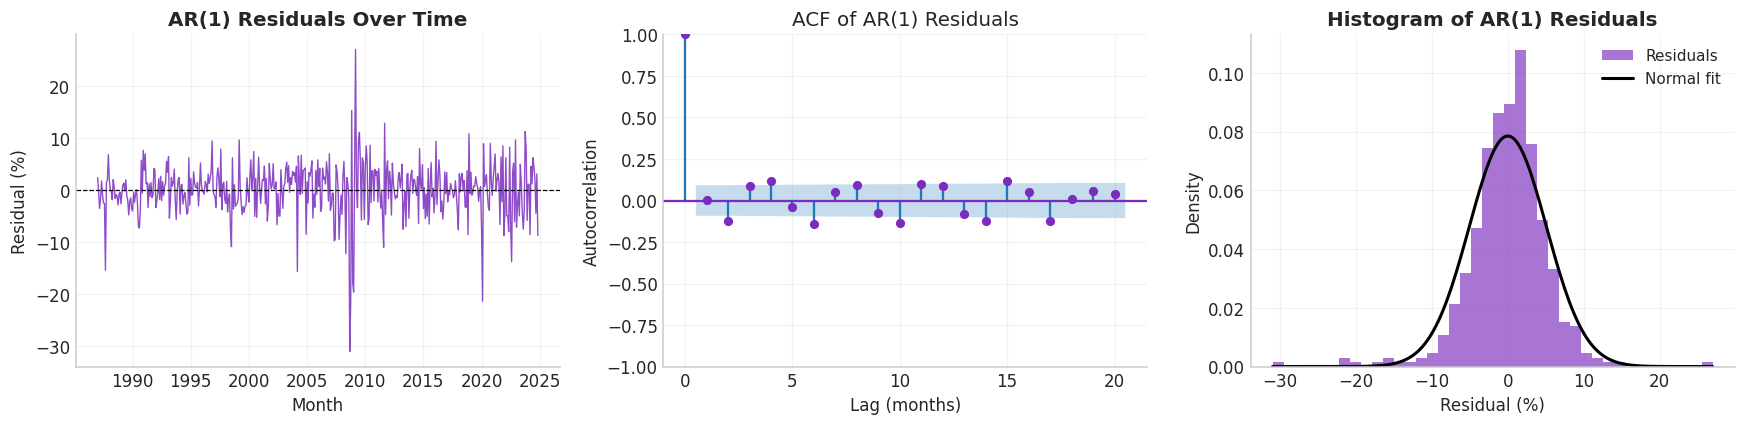

Chart saved: fig05_residual_diagnostics.png


In [ ]:
# =============================================================================
# RESIDUAL DIAGNOSTICS — Selected AR model
# =============================================================================
vwtret_series = df_factors["vwtret"]
candidate_models = {lag: AutoReg(vwtret_series, lags=lag, old_names=False).fit() for lag in range(1, 5)}
selected_lag = min(candidate_models, key=lambda lag: candidate_models[lag].bic)
selected_model = candidate_models[selected_lag]
selected_residuals = selected_model.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(selected_residuals.index, selected_residuals.values, color=COLOR_RESIDUAL, linewidth=0.9)
axes[0, 0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0, 0].set_title(f"Residuals Over Time: AR({selected_lag})", fontweight="bold")
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("Residual (%)")

plot_acf(selected_residuals, lags=20, ax=axes[0, 1], color=COLOR_RESIDUAL, alpha=0.05, title="Residual ACF")
axes[0, 1].set_xlabel("Lag (months)")
axes[0, 1].set_ylabel("Autocorrelation")

axes[1, 0].hist(selected_residuals, bins=35, color=COLOR_RESIDUAL, alpha=0.7, density=True)
axes[1, 0].set_title("Residual Histogram", fontweight="bold")
axes[1, 0].set_xlabel("Residual (%)")
axes[1, 0].set_ylabel("Density")

sm.qqplot(selected_residuals, line="45", ax=axes[1, 1], markerfacecolor=COLOR_RESIDUAL, markeredgecolor=COLOR_RESIDUAL, alpha=0.45)
axes[1, 1].set_title("Residual Q-Q Plot", fontweight="bold")

fig.suptitle(f"Residual Diagnostics for AR({selected_lag})", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(DEMOS_DIR / "fig05_residual_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

print_rule("Residual Snapshot")
print(f"Residual standard deviation: {selected_residuals.std():.3f}%")
print(f"Mean residual: {selected_residuals.mean():.3f}%")

In [ ]:
# =============================================================================
# LJUNG-BOX TEST — Formal residual autocorrelation check
# =============================================================================
lb_test_result = acorr_ljungbox(selected_residuals, lags=[5, 10, 15], return_df=True)
lb_test_result["Pass at 5%?"] = lb_test_result["lb_pvalue"] > 0.05

print_rule(f"Ljung-Box Test for AR({selected_lag}) Residuals")
print("Null hypothesis: there is no residual autocorrelation up to the stated lag.")
display(lb_test_result.round(4))

if (lb_test_result["lb_pvalue"] > 0.05).all():
    print("Overall reading: the residuals look consistent with white noise at the tested lags.")
else:
    print("Overall reading: the model removes a lot of dependence, but some residual structure may still remain at longer lags.")

Ljung-Box Test: Are AR(1) Residuals White Noise?
H0: No autocorrelation in residuals

    lb_stat  lb_pvalue
5    17.465      0.004
10   43.133      0.000
15   67.957      0.000

  Lag  5: stat = 17.465, p = 0.0037  →  FAIL (autocorrelation detected)
  Lag 10: stat = 43.133, p = 0.0000  →  FAIL (autocorrelation detected)
  Lag 15: stat = 67.957, p = 0.0000  →  FAIL (autocorrelation detected)


### Interpretation Checkpoint

This section gives a more honest picture than the model summary alone.

For the preferred AR(4) model:

- the short-lag residual autocorrelation is much smaller than it was under AR(1)
- the Ljung-Box results look acceptable at 5 and 10 lags
- by 15 lags, the result is only borderline, which tells us the model is improved but not perfect

That is a good teaching outcome for beginners: a model does not need to be perfect to be useful, but we should be explicit about what it still misses.

---

## Section 8: 12-Month Forecast

Now we use the selected autoregressive model to forecast the next 12 months of REIT returns.

Two ideas are worth watching for:

1. **Short-run movement** can depend on the recent history of returns.
2. **Long-run forecasts** tend to move back toward the historical average when the process is stationary.

The confidence interval matters as much as the point forecast. A point forecast by itself can look precise even when the uncertainty is large.

In [ ]:
# =============================================================================
# 12-MONTH AHEAD FORECAST WITH 95% CONFIDENCE INTERVALS
# =============================================================================
vwtret_series = df_factors["vwtret"]
candidate_models = {lag: AutoReg(vwtret_series, lags=lag, old_names=False).fit() for lag in range(1, 5)}
selected_lag = min(candidate_models, key=lambda lag: candidate_models[lag].bic)
selected_model = candidate_models[selected_lag]

n_forecast_months = 12
forecast_object = selected_model.get_prediction(
    start=len(vwtret_series),
    end=len(vwtret_series) + n_forecast_months - 1,
    dynamic=True,
)
forecast_summary = forecast_object.summary_frame(alpha=0.05)
forecast_values = forecast_summary["mean"]
conf_int_lower = forecast_summary["mean_ci_lower"]
conf_int_upper = forecast_summary["mean_ci_upper"]

last_observed_date = vwtret_series.index[-1]
forecast_dates = pd.date_range(
    start=last_observed_date + pd.DateOffset(months=1),
    periods=n_forecast_months,
    freq="MS",
)
forecast_values.index = forecast_dates
conf_int_lower.index = forecast_dates
conf_int_upper.index = forecast_dates

forecast_table = pd.DataFrame(
    {
        "Forecast (%)": forecast_values,
        "Lower 95%": conf_int_lower,
        "Upper 95%": conf_int_upper,
    }
).round(3)

print_rule(f"12-Month Forecast from AR({selected_lag})")
display(forecast_table)

12-Month Forecast: REIT Value-Weighted Returns (%)
Month             Forecast    Lower 95%    Upper 95%
----------------------------------------------------
Dec 2024             0.546       -9.400       10.492
Jan 2025             0.796       -9.155       10.746
Feb 2025             0.803       -9.147       10.754
Mar 2025             0.803       -9.147       10.754
Apr 2025             0.803       -9.147       10.754
May 2025             0.803       -9.147       10.754
Jun 2025             0.803       -9.147       10.754
Jul 2025             0.803       -9.147       10.754
Aug 2025             0.803       -9.147       10.754
Sep 2025             0.803       -9.147       10.754
Oct 2025             0.803       -9.147       10.754
Nov 2025             0.803       -9.147       10.754


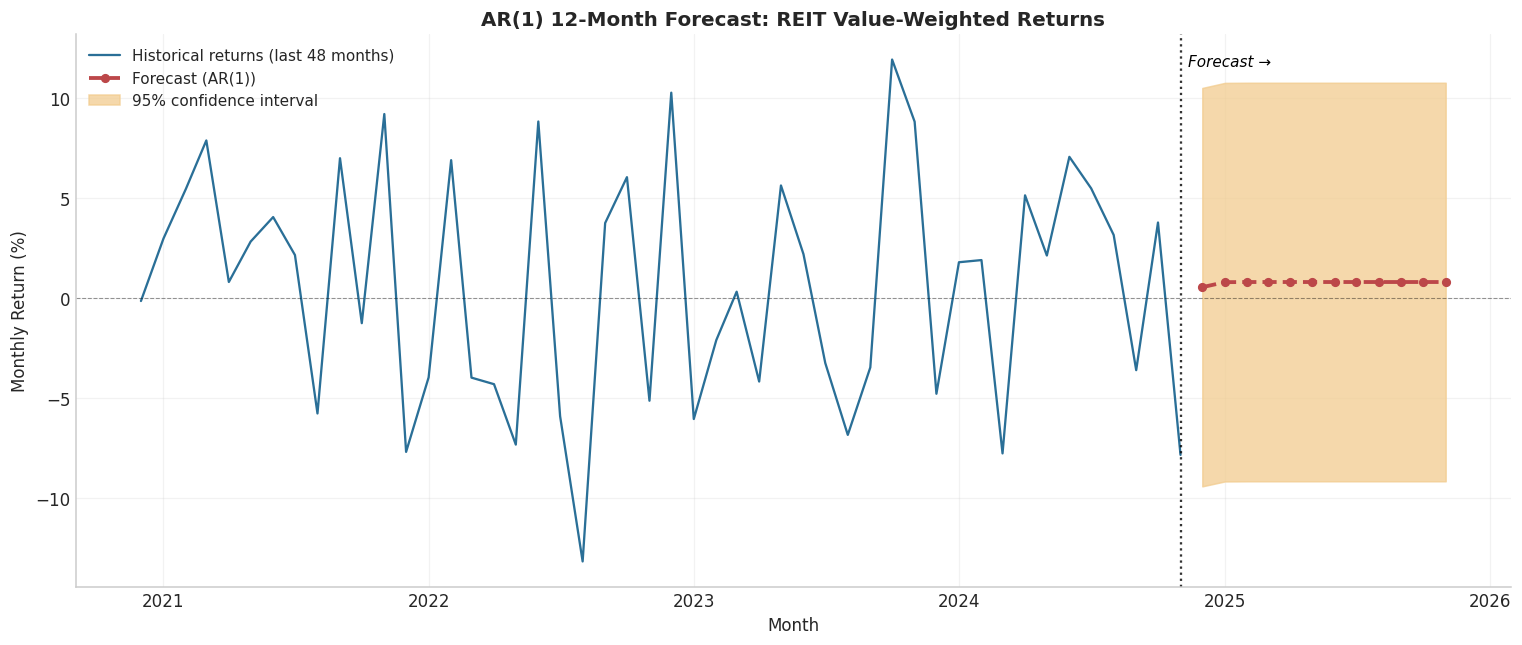

Chart saved: fig06_forecast.png

95% CI width at 1-month horizon:  19.89 percentage points
95% CI width at 12-month horizon: 19.90 percentage points
→ The uncertainty band is 1.0x wider at month 12 than month 1.


In [ ]:
# =============================================================================
# CHART 6 — Forecast plot: recent history + 12-month ahead forecast
# =============================================================================
n_historical_months_to_show = 60
recent_returns = vwtret_series.iloc[-n_historical_months_to_show:]

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(recent_returns.index, recent_returns.values, color=COLOR_RETURNS, linewidth=1.5, label="Historical returns")
ax.plot(forecast_dates, forecast_values.values, color=COLOR_FORECAST, linewidth=2.2, linestyle="--", marker="o", markersize=4, label=f"Forecast: AR({selected_lag})")
ax.fill_between(forecast_dates, conf_int_lower.values, conf_int_upper.values, color=COLOR_CI, alpha=0.75, label="95% confidence interval")
ax.axvline(x=last_observed_date, color="black", linewidth=1.2, linestyle=":")
ax.axhline(vwtret_series.mean(), color="#C1121F", linewidth=1.1, linestyle=":", label=f"Sample mean = {vwtret_series.mean():.2f}%")
ax.axhline(0, color="black", linewidth=0.7, linestyle="--", alpha=0.5)

ax.text(last_observed_date + pd.DateOffset(days=10), ax.get_ylim()[1] * 0.85, "Forecast region", fontsize=10)
ax.set_title(f"12-Month Forecast for REIT Returns Using AR({selected_lag})", fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Monthly return (%)")
ax.legend(loc="upper left", frameon=True)

plt.tight_layout()
plt.savefig(DEMOS_DIR / "fig06_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

ci_width_month1 = conf_int_upper.iloc[0] - conf_int_lower.iloc[0]
ci_width_month12 = conf_int_upper.iloc[-1] - conf_int_lower.iloc[-1]

print_rule("Forecast Uncertainty")
print(f"95% interval width at month 1:  {ci_width_month1:.2f} percentage points")
print(f"95% interval width at month 12: {ci_width_month12:.2f} percentage points")
print("The interval stays wide throughout the forecast horizon, which is a reminder that return direction is hard to pin down precisely.")

### Interpretation Checkpoint

The forecast does **not** say that returns become easy to predict once we fit a model.

What it shows is more modest:

- the first few forecasted months react to the recent pattern in returns
- after that, the forecast settles back near the historical mean
- the confidence interval remains wide, roughly spanning about +/-10 percentage points around the center

That combination is a very realistic outcome for financial returns:

- some short-run structure
- a stable long-run mean
- substantial uncertainty at every horizon

---

## Section 9: What Can We Honestly Forecast?

This is where interpretation matters more than coding.

The results in this notebook support three claims at the same time:

1. REIT returns are stationary enough to model.
2. There is some autocorrelation structure in the sample.
3. Forecast uncertainty is still large.

That combination is not contradictory. It simply means that a series can be statistically modelable without being highly predictable.

### A Good Beginner Summary

- The model captures **some** dependence on past returns.
- The model does **not** explain most month-to-month variation.
- A wide forecast interval is not a failure. It is the honest output when the signal is weak relative to the noise.

### Why This Matters in Finance

Financial returns are difficult because markets absorb information quickly. Even when a time-series model finds a pattern, the pattern is often small relative to the random variation in monthly returns.

So the correct takeaway is not "the model is useless."

The correct takeaway is:

> The model helps us describe the data and organize our uncertainty, but it does not give a precise crystal ball.

---

## Section 10: Comparing REIT Returns with the Momentum Factor

A useful final question is whether another return series shows a noticeably different autocorrelation pattern.

We compare REIT returns with the momentum factor.

The point of this section is not to force a dramatic difference. The point is to look carefully at what the sample actually shows.

If the two ACF plots look similar, that is still informative. It tells us that apparent persistence can be weaker in a particular sample than our prior story might suggest.

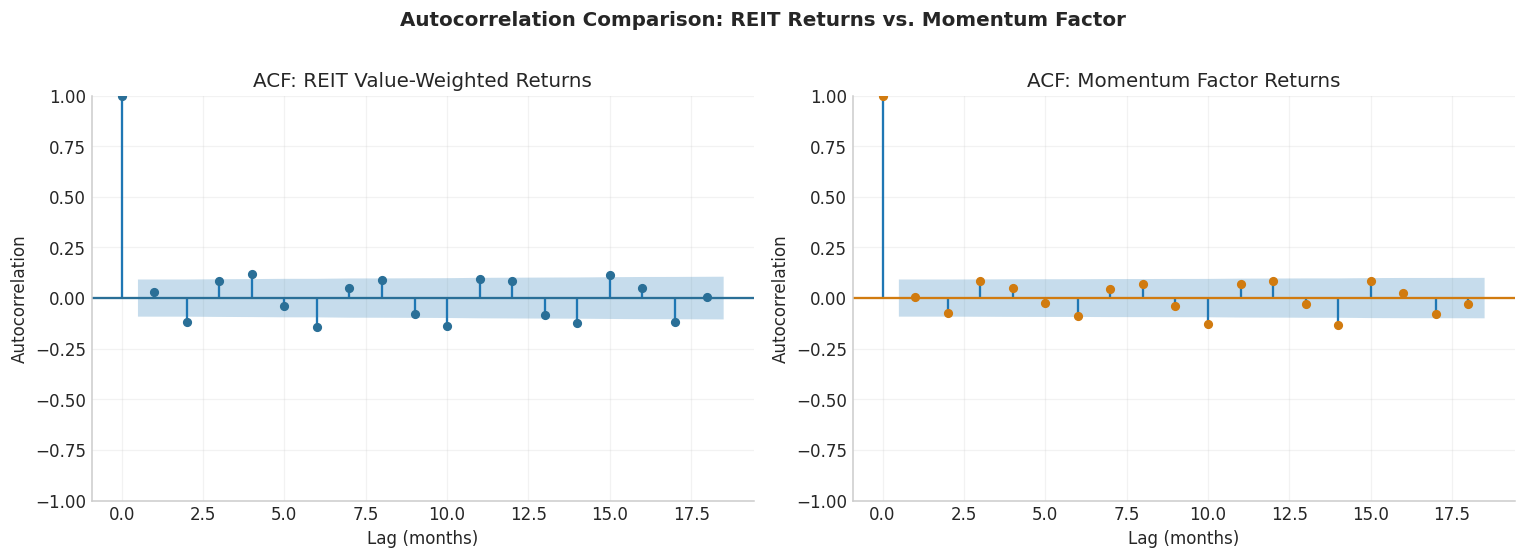

Chart saved: fig07_acf_comparison.png

Lag        REIT Returns ACF     Momentum ACF
--------------------------------------------
1                    0.0296           0.0030
2                   -0.1187          -0.0746
3                    0.0854           0.0832


In [ ]:
# =============================================================================
# CHART 7 — ACF comparison: REIT returns vs. momentum factor
# =============================================================================
vwtret_series = df_factors["vwtret"].dropna()
mom_series = df_factors["mom_long"].dropna()

common_dates = vwtret_series.index.intersection(mom_series.index)
vwtret_aligned = vwtret_series.loc[common_dates]
mom_aligned = mom_series.loc[common_dates]

n_lags_compare = 18

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(
    vwtret_aligned,
    lags=n_lags_compare,
    ax=axes[0],
    color=COLOR_RETURNS,
    alpha=0.05,
    title="ACF: REIT Returns",
)
axes[0].set_xlabel("Lag (months)")
axes[0].set_ylabel("Autocorrelation")

plot_acf(
    mom_aligned,
    lags=n_lags_compare,
    ax=axes[1],
    color=COLOR_MOMENTUM,
    alpha=0.05,
    title="ACF: Momentum Factor",
)
axes[1].set_xlabel("Lag (months)")
axes[1].set_ylabel("Autocorrelation")

fig.suptitle("ACF Comparison: REIT Returns vs. Momentum Factor", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(DEMOS_DIR / "fig07_acf_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

acf_vwt = acf(vwtret_aligned, nlags=6, fft=True)
acf_mom = acf(mom_aligned, nlags=6, fft=True)
comparison_table = pd.DataFrame(
    {
        "Lag": range(1, 7),
        "REIT ACF": acf_vwt[1:7],
        "Momentum ACF": acf_mom[1:7],
    }
).round(3)

print_rule("ACF Comparison Table")
display(comparison_table)

### What Do You Notice?

In this particular sample, the two series are **not dramatically different** at short horizons.

That is an important teaching point by itself.

- REIT returns show modest autocorrelation at a few lags.
- The momentum factor also shows only modest sample autocorrelation here.
- So we should avoid forcing a stronger conclusion than the plot supports.

The habit to build is simple:

> Let the sample evidence lead the interpretation, even when it is quieter than the textbook story.

---

## Section 11: Summary and Key Takeaways

We have covered the complete lifecycle of a basic time-series analysis:

1. **Visual inspection** of returns vs. price levels.
2. **Formal testing** for stationarity using the ADF test.
3. **Internal structure** analysis using ACF and PACF plots.
4. **Model selection** comparing AR(1) through AR(4) with info criteria.
5. **Residual diagnostics** to ensure the model captured the signal.
6. **Forecasting** while being transparent about uncertainty.

### Final Lessons for Beginners

- **Don't mistake "modelable" for "predictable."** We can fit a statistically sound model that still has low forecasting power.
- **Stationarity is a must.** If you try to model a non-stationary price index directly, your statistics will be misleading.
- **Confidence intervals are your friend.** In finance, the range of possible outcomes matters as much as the single best guess.

### Connection to Your Assignment

When you work on Assignment 12, use this notebook as your template.

- Check your dates and frequencies.
- Look at the ACF/PACF before you run the models.
- If BIC prefers a simpler model, follow its lead.
- Always explain what your forecast intervals mean in plain English.

---
**End of Demo**